# Bulk Reconstruction and Entanglement Wedge Analysis

This notebook demonstrates the cartography module for bulk reconstruction using the protocol from Brian Swingle's MATLAB code.

## Overview

The cartography module implements:
1. **Subsystem extraction**: Extract reduced covariance matrices for boundary subregions
2. **Bulk probe insertion**: Add probe nodes at bulk positions as boundary nodes in group b1
3. **Post-measurement states**: Generate covariance after measuring out ancilla
4. **Entropy calculations**: Compute S_b, S_R, S_{R+b}, S_{R^c}, S_{R^c+b}, and I(R:b)
5. **Bulk reconstruction sweeps**: Map entanglement wedge structure by varying bulk position and region size

## Key Concepts

**Bulk Probe**: A boundary node in group b1 (separate from main boundary b0) that allows measuring mutual information I(R:b) between boundary region R and bulk point b.

**Entanglement Wedge**: Region of bulk that is maximally entangled with a given boundary region. Characterized by I(R:b) > 0.

**Protocol**:
1. Start with MERA graph (boundary + ancilla nodes)
2. Add bulk probe at position of interest (becomes boundary node in b1)
3. Apply quench evolution (weighted or unweighted)
4. Measure out all ancilla via homodyne measurement (P basis)
5. Compute mutual information between boundary regions and bulk probe

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import loadconfig as loco

from graph2grav.graphs.standard import crosslinked_tree, make_tree_periodic, tree_node_depth
from graph2grav.cartography import (
    extract_subsystem_covariance,
    mutual_information,
    add_bulk_node,
    get_post_measurement_covariance,
    compute_bulk_entropies,
    sweep_bulk_reconstruction,
    plot_mutual_info_vs_region_size,
    plot_mutual_info_heatmap,
    plot_entropy_components,
    plot_wedge_boundary,
)
from graph2grav import gaussian

# Load global figure settings
config = loco.reload()

## 1. Create MERA Graph

We start by creating a MERA (Multi-scale Entanglement Renormalization Ansatz) graph using the crosslinked tree structure with periodic boundary conditions.

Crosslinked tree: 127 nodes, 246 edges
MERA graph: 127 nodes, 251 edges

Boundary nodes (64): [63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Ancilla nodes (63): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]


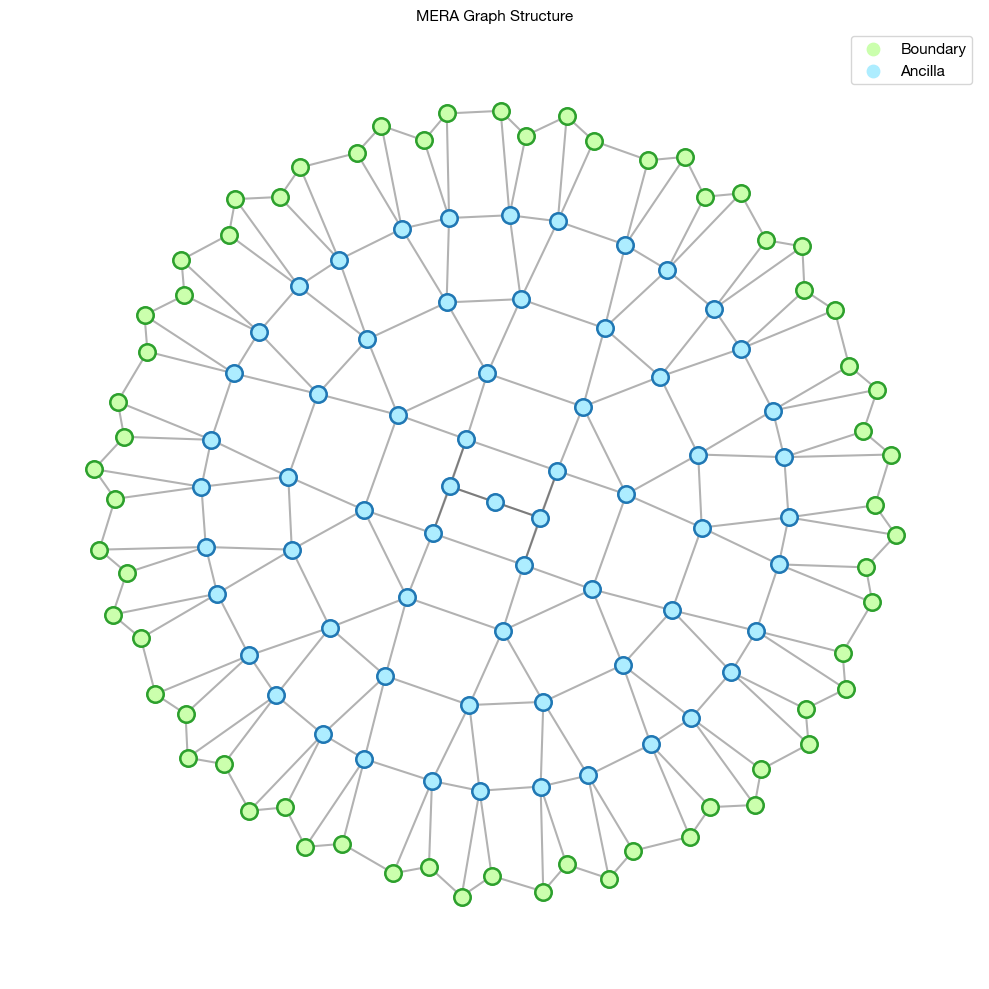

In [2]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}
%matplotlib inline

# Create crosslinked tree with depth 4 (16 boundary nodes)
G_tree = crosslinked_tree(depth=6)
print(f"Crosslinked tree: {G_tree.number_of_nodes()} nodes, {G_tree.number_of_edges()} edges")

# Make periodic and remove unnecessary nodes
G = make_tree_periodic(G_tree, remove_nodes=False)
print(f"MERA graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Identify node types
boundary_nodes = sorted([n for n, d in G.nodes(data=True) if d.get('is_boundary', False)])
ancilla_nodes = sorted([n for n, d in G.nodes(data=True) if d.get('is_ancilla', False)])

print(f"\nBoundary nodes ({len(boundary_nodes)}): {boundary_nodes}")
print(f"Ancilla nodes ({len(ancilla_nodes)}): {ancilla_nodes}")

# Visualize the graph using config colors
fig, ax = plt.subplots(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3, width=config["graph"]["linewidth"], ax=ax)

# Draw boundary nodes with double circle (inner + outer)
nx.draw_networkx_nodes(G, pos, nodelist=boundary_nodes, 
                       node_color=config["graph"]["nodes"]["boundary"]["outer"]["color"], 
                       node_size=config["graph"]["nodes"]["boundary"]["outer"]["size"]*2,
                       ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=boundary_nodes, 
                       node_color=config["graph"]["nodes"]["boundary"]["inner"]["color"], 
                       node_size=config["graph"]["nodes"]["boundary"]["outer"]["size"],
                       label='Boundary', ax=ax)

# Draw ancilla nodes with double circle
nx.draw_networkx_nodes(G, pos, nodelist=ancilla_nodes, 
                       node_color=config["graph"]["nodes"]["ancilla"]["outer"]["color"], 
                       node_size=config["graph"]["nodes"]["ancilla"]["outer"]["size"]*2,
                       ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=ancilla_nodes, 
                       node_color=config["graph"]["nodes"]["ancilla"]["inner"]["color"], 
                       node_size=config["graph"]["nodes"]["ancilla"]["outer"]["size"],
                       label='Ancilla', ax=ax)

# Add labels if configured
if config["graph"]["which_nodes_to_label"] != "none":
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

ax.legend()
ax.set_title('MERA Graph Structure')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Add Bulk Probe Node

We add a bulk probe node at a specified position. The probe is added as a boundary node in group b1 (separate from main boundary b0).

Adding bulk probe at node 25

Extended graph: 128 nodes, 252 edges
Bulk probe node ID: 127
Number of boundaries: 2

Bulk probe attributes:
  is_boundary: True
  is_ancilla: False
  is_bulk_probe: True
  b0: False
  b1: True
  boundary_index: 1
  position_in_boundary: 0
  region: probe


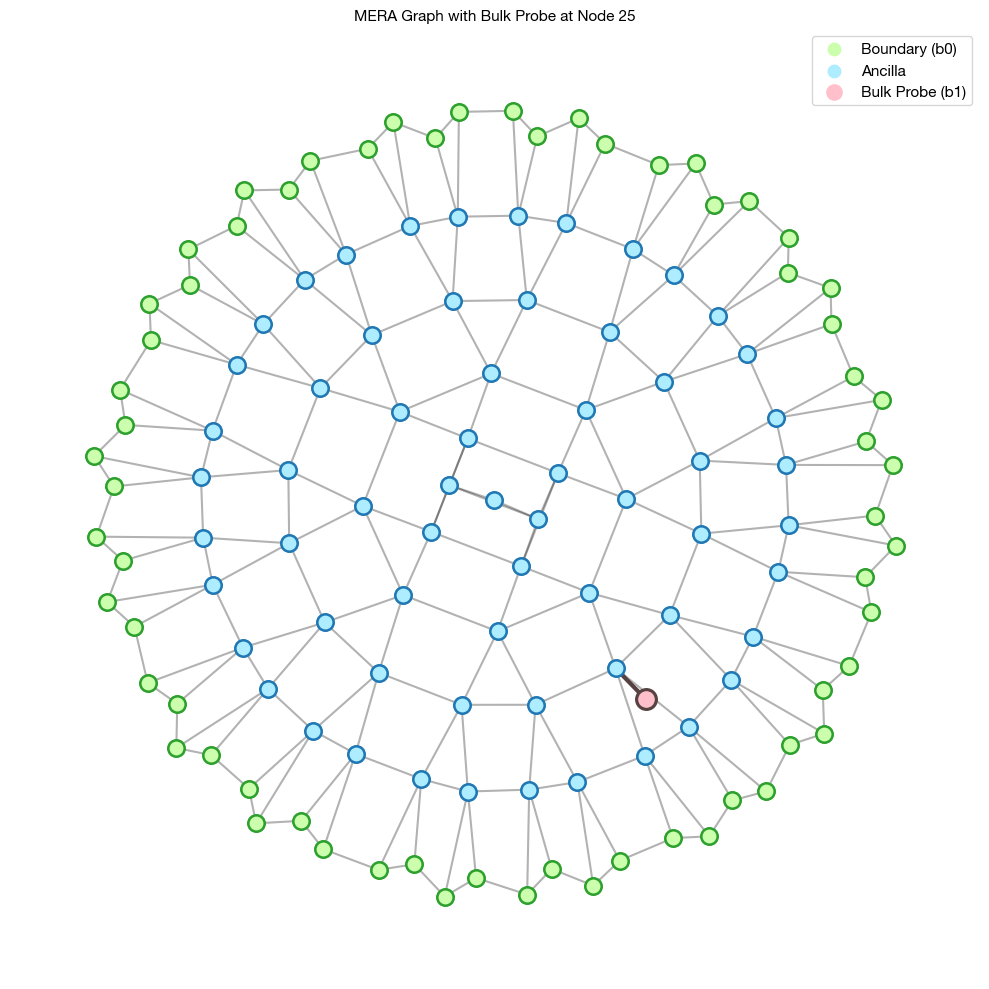

In [3]:
# Choose a bulk position (ancilla node in the middle layers)
bulk_position = 25 # ancilla_nodes[len(ancilla_nodes)//2]
print(f"Adding bulk probe at node {bulk_position}")

# Add bulk probe
G_ext, bulk_id = add_bulk_node(G, bulk_position, coupling=1.0)

print(f"\nExtended graph: {G_ext.number_of_nodes()} nodes, {G_ext.number_of_edges()} edges")
print(f"Bulk probe node ID: {bulk_id}")
print(f"Number of boundaries: {G_ext.graph['number_of_boundaries']}")

# Check bulk probe attributes
print(f"\nBulk probe attributes:")
for key, value in G_ext.nodes[bulk_id].items():
    if key != 'graph':  # Skip graph reference
        print(f"  {key}: {value}")

# Visualize extended graph using config colors
fig, ax = plt.subplots(figsize=(10, 10))
pos_ext = nx.kamada_kawai_layout(G_ext)

# Draw edges
nx.draw_networkx_edges(G_ext, pos_ext, alpha=0.3, width=config["graph"]["linewidth"], ax=ax)

# Highlight edge to bulk probe
nx.draw_networkx_edges(G_ext, pos_ext, edgelist=[(bulk_position, bulk_id)], 
                       edge_color=config["graph"]["nodes"]["selected_boundary"]["outer"]["color"], 
                       width=3, ax=ax)

# Draw boundary nodes (b0) with double circle
nx.draw_networkx_nodes(G_ext, pos_ext, nodelist=boundary_nodes, 
                       node_color=config["graph"]["nodes"]["boundary"]["outer"]["color"], 
                       node_size=config["graph"]["nodes"]["boundary"]["outer"]["size"]*2,
                       ax=ax)
nx.draw_networkx_nodes(G_ext, pos_ext, nodelist=boundary_nodes, 
                       node_color=config["graph"]["nodes"]["boundary"]["inner"]["color"], 
                       node_size=config["graph"]["nodes"]["boundary"]["outer"]["size"],
                       label='Boundary (b0)', ax=ax)

# Draw ancilla nodes with double circle
nx.draw_networkx_nodes(G_ext, pos_ext, nodelist=ancilla_nodes, 
                       node_color=config["graph"]["nodes"]["ancilla"]["outer"]["color"], 
                       node_size=config["graph"]["nodes"]["ancilla"]["outer"]["size"]*2,
                       ax=ax)
nx.draw_networkx_nodes(G_ext, pos_ext, nodelist=ancilla_nodes, 
                       node_color=config["graph"]["nodes"]["ancilla"]["inner"]["color"], 
                       node_size=config["graph"]["nodes"]["ancilla"]["outer"]["size"],
                       label='Ancilla', ax=ax)

# Draw bulk probe (b1) with double circle using selected_boundary colors
nx.draw_networkx_nodes(G_ext, pos_ext, nodelist=[bulk_id], 
                       node_color=config["graph"]["nodes"]["selected_boundary"]["outer"]["color"], 
                       node_size=config["graph"]["nodes"]["selected_boundary"]["outer"]["size"]*3,
                       ax=ax)
nx.draw_networkx_nodes(G_ext, pos_ext, nodelist=[bulk_id], 
                       node_color=config["graph"]["nodes"]["selected_boundary"]["inner"]["color"], 
                       node_size=config["graph"]["nodes"]["selected_boundary"]["outer"]["size"]*1.5,
                       label='Bulk Probe (b1)', ax=ax)

# Add labels if configured
if config["graph"]["which_nodes_to_label"] != "none":
    nx.draw_networkx_labels(G_ext, pos_ext, font_size=8, ax=ax)

ax.legend()
ax.set_title(f'MERA Graph with Bulk Probe at Node {bulk_position}')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Generate Post-Measurement Covariance

We generate the covariance matrix after:
1. Applying quench evolution (unweighted)
2. Measuring out all ancilla nodes via homodyne measurement in P basis

The result is a reduced covariance matrix for boundary nodes (b0 + b1).

Post-measurement covariance shape: (130, 130)
Kept node indices: [63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127]
Bulk probe is at index 64 in kept indices
Bulk probe node ID: 127

Symplectic eigenvalues:
  Min: 0.500000
  Max: 0.500000
  All >= 0.5: True


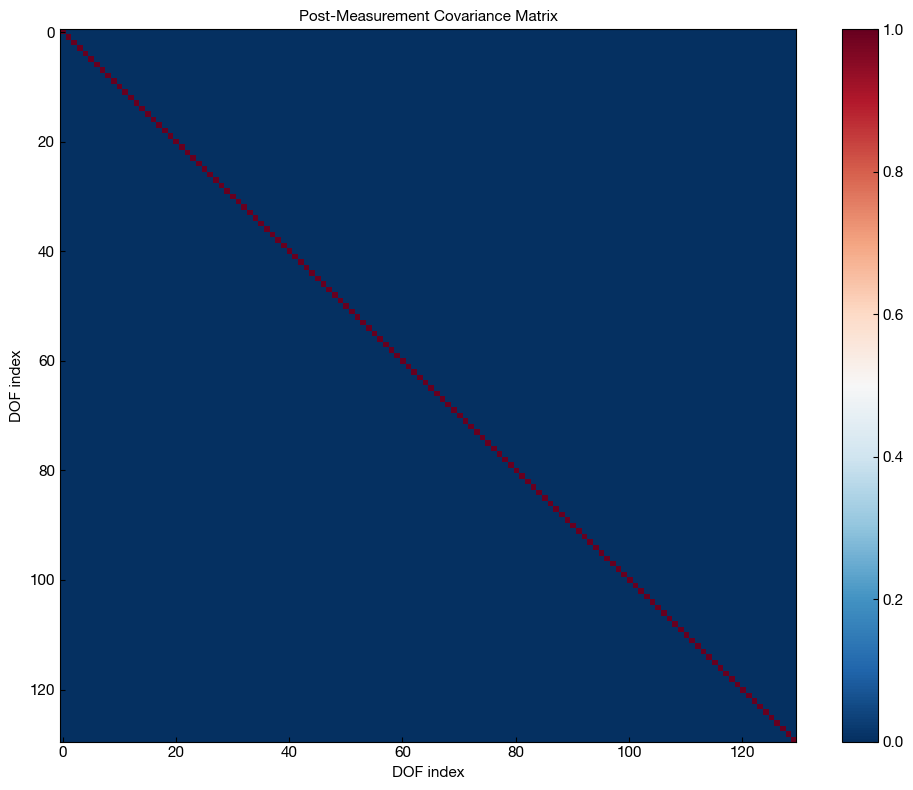

In [4]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}
%matplotlib inline

# Generate post-measurement covariance (unweighted quench)
cov_post, kept_indices, bulk_idx = get_post_measurement_covariance(
    G_ext, bulk_id,
    use_weighted=False,
    couplingtime=0.0
)

print(f"Post-measurement covariance shape: {cov_post.shape}")
print(f"Kept node indices: {kept_indices}")
print(f"Bulk probe is at index {bulk_idx} in kept indices")
print(f"Bulk probe node ID: {kept_indices[bulk_idx]}")

# Check that covariance is physical (all symplectic eigenvalues >= 1/2)
N = cov_post.shape[0] // 2
Omega = np.block([[np.zeros((N, N)), np.eye(N)],
                 [-np.eye(N), np.zeros((N, N))]])
symeigs = gaussian.symeigvals(cov_post, Omega) / 2

print(f"\nSymplectic eigenvalues:")
print(f"  Min: {np.min(symeigs):.6f}")
print(f"  Max: {np.max(symeigs):.6f}")
print(f"  All >= 0.5: {np.all(symeigs >= 0.5 - 1e-10)}")

# Visualize covariance matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cov_post, cmap='RdBu_r', aspect='auto')
ax.set_title('Post-Measurement Covariance Matrix')
ax.set_xlabel('DOF index')
ax.set_ylabel('DOF index')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 4. Compute Entropies for a Single Configuration

For a given boundary region R, we compute:
- S_b: Entropy of bulk probe alone
- S_R: Entropy of boundary region R
- S_{R+b}: Joint entropy of R and bulk
- S_{R^c}: Entropy of complement region
- S_{R^c+b}: Joint entropy of complement and bulk
- I(R:b): Mutual information between R and bulk

In [5]:
# Define a boundary region R (first half of boundary)
region_size = len(boundary_nodes) // 2
region_nodes = boundary_nodes[:region_size]

# Map node IDs to indices in kept array
node_to_idx = {node: idx for idx, node in enumerate(kept_indices)}
region_indices = [node_to_idx[n] for n in region_nodes]

print(f"Region R: {region_size} boundary nodes")
print(f"Region node IDs: {region_nodes}")
print(f"Region indices in covariance: {region_indices}")

# Compute all entropies
entropies = compute_bulk_entropies(
    cov_post, region_indices, bulk_idx, len(kept_indices)
)

print(f"\nEntropy Results:")
print(f"  S_b (bulk):              {entropies['S_b']:.6f}")
print(f"  S_R (region):            {entropies['S_R']:.6f}")
print(f"  S_{{R+b}} (joint):          {entropies['S_R_b']:.6f}")
print(f"  S_{{R^c}} (complement):     {entropies['S_Rc']:.6f}")
print(f"  S_{{R^c+b}} (comp+bulk):    {entropies['S_Rc_b']:.6f}")
print(f"  I(R:b) (mutual info):    {entropies['MI_R_b']:.6f}")

# Verify MI formula
MI_check = entropies['S_R'] + entropies['S_b'] - entropies['S_R_b']
print(f"\nVerification: S_R + S_b - S_{{R+b}} = {MI_check:.6f}")
print(f"Matches I(R:b): {np.isclose(MI_check, entropies['MI_R_b'])}")

# Check physics bounds
print(f"\nPhysics Checks:")
print(f"  I(R:b) >= 0: {entropies['MI_R_b'] >= -1e-10}")
print(f"  I(R:b) <= S_R + S_b: {entropies['MI_R_b'] <= entropies['S_R'] + entropies['S_b'] + 1e-10}")
print(f"  Subadditivity S_{{R+b}} <= S_R + S_b: {entropies['S_R_b'] <= entropies['S_R'] + entropies['S_b'] + 1e-10}")

Region R: 32 boundary nodes
Region node IDs: [63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
Region indices in covariance: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

Entropy Results:
  S_b (bulk):              0.000000
  S_R (region):            0.000000
  S_{R+b} (joint):          0.000000
  S_{R^c} (complement):     0.000000
  S_{R^c+b} (comp+bulk):    0.000000
  I(R:b) (mutual info):    0.000000

Verification: S_R + S_b - S_{R+b} = 0.000000
Matches I(R:b): True

Physics Checks:
  I(R:b) >= 0: True
  I(R:b) <= S_R + S_b: True
  Subadditivity S_{R+b} <= S_R + S_b: True


## 5. Sweep Over Region Sizes

We fix the bulk position and vary the boundary region size to see how mutual information changes.

In [6]:
# Sweep over region sizes for a single bulk position
region_sizes = list(range(1, len(boundary_nodes) + 1))

results_single_bulk = sweep_bulk_reconstruction(
    G, [bulk_position], region_sizes,
    use_weighted=False,
    verbose=True,
    couplingtime=200
)

print(f"\nGenerated {len(results_single_bulk)} results")
print(f"\nFirst few results:")
for i, r in enumerate(results_single_bulk[:5]):
    print(f"  Region size {r['region_size']}: I(R:b) = {r['MI_R_b']:.6f}")

Bulk positions:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jonathan/lab/gravity/graph2grav/graph2grav/cartography/reconstruction.py:130: UserWarning: Covariance BEFORE measurement is already unphysical! Min symeig: 0.500000
  warnings.warn(f"Covariance BEFORE measurement is already unphysical! Min symeig: {min_symeig_full:.6f}")


Bulk positions: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

Bulk positions: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]


Generated 64 results

First few results:
  Region size 1: I(R:b) = 0.001250
  Region size 2: I(R:b) = 0.001453
  Region size 3: I(R:b) = 0.005968
  Region size 4: I(R:b) = 0.015502
  Region size 5: I(R:b) = 0.021774


## 6. Visualize I(R:b) vs Region Size

Plot mutual information as a function of boundary region size for a fixed bulk position.

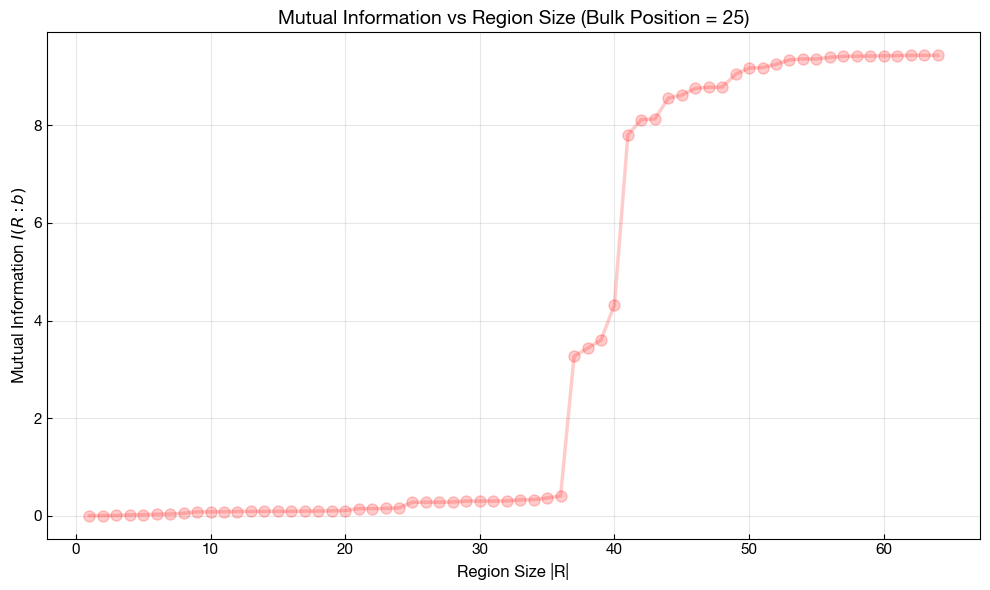

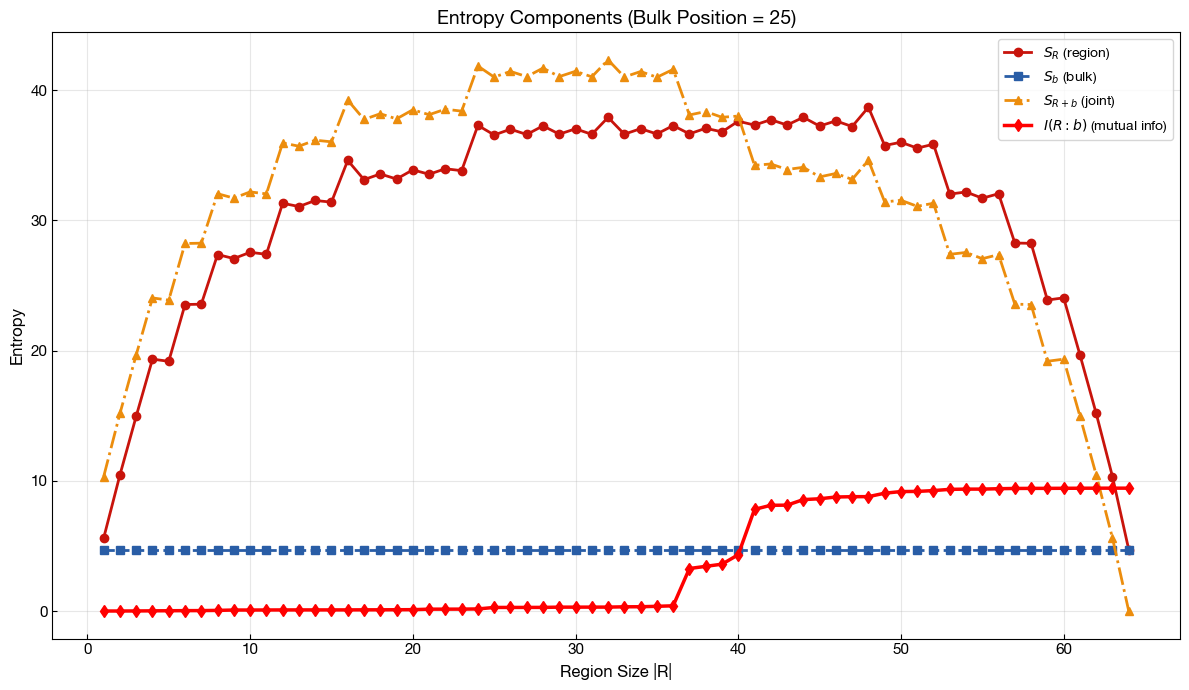

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_mutual_info_vs_region_size(results_single_bulk, bulk_position, ax=ax)

plt.tight_layout()
plt.show()

# Also plot all entropy components
fig, ax = plt.subplots(figsize=(12, 7))

plot_entropy_components(results_single_bulk, bulk_position, ax=ax)

plt.tight_layout()
plt.show()

## 7. Full Sweep: Multiple Bulk Positions and Region Sizes

Now we sweep over multiple bulk positions to map out the entanglement wedge structure.

In [8]:
# Select a subset of ancilla nodes to test as bulk positions
# (testing all can be slow for large graphs)
num_bulk_positions = len(ancilla_nodes)
bulk_positions = ancilla_nodes[:num_bulk_positions]

print(f"Testing {len(bulk_positions)} bulk positions")
print(f"Testing {len(region_sizes)} region sizes")
print(f"Total configurations: {len(bulk_positions) * len(region_sizes)}")

# Run sweep
results_full = sweep_bulk_reconstruction(
    G, bulk_positions, region_sizes,
    use_weighted=False,
    verbose=True,
    coupling=1,
    couplingtime=0.5
)

print(f"\nGenerated {len(results_full)} results")

# Show statistics
MI_values = [r['MI_R_b'] for r in results_full]
print(f"\nMutual Information Statistics:")
print(f"  Min: {np.min(MI_values):.6f}")
print(f"  Max: {np.max(MI_values):.6f}")
print(f"  Mean: {np.mean(MI_values):.6f}")
print(f"  Std: {np.std(MI_values):.6f}")

Testing 63 bulk positions
Testing 64 region sizes
Total configurations: 4032


Bulk positions:   0%|          | 0/63 [00:00<?, ?it/s]

Bulk positions:   2%|▏         | 1/63 [00:00<00:23,  2.61it/s]

Bulk positions:   3%|▎         | 2/63 [00:00<00:22,  2.69it/s]

Bulk positions:   5%|▍         | 3/63 [00:01<00:21,  2.77it/s]

...

Bulk positions:  97%|█████████▋| 61/63 [00:21<00:00,  2.85it/s]

Bulk positions:  98%|█████████▊| 62/63 [00:21<00:00,  2.86it/s]

Bulk positions: 100%|██████████| 63/63 [00:22<00:00,  2.86it/s]

Bulk positions: 100%|██████████| 63/63 [00:22<00:00,  2.83it/s]


Generated 4032 results

Mutual Information Statistics:
  Min: 0.000000
  Max: 0.130476
  Mean: 0.039336
  Std: 0.053053


## 8. Visualize Entanglement Wedge Heatmap

Create a heatmap showing I(R:b) as a function of bulk position and region size.

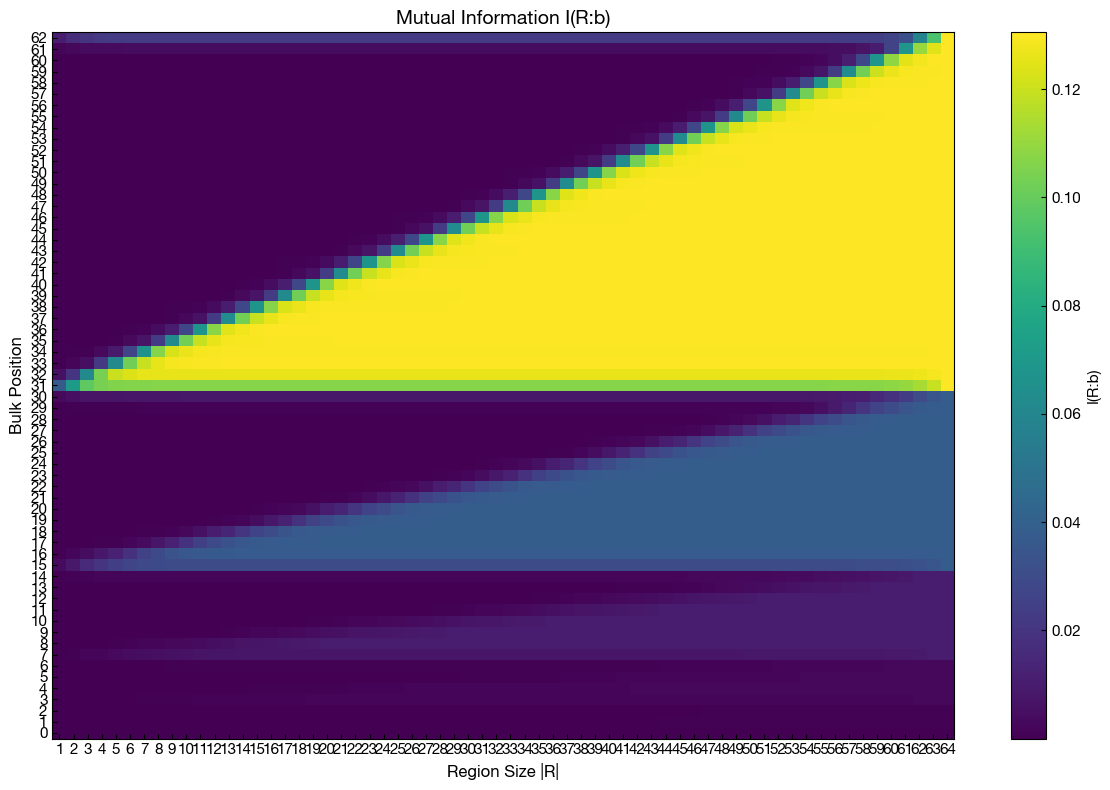

In [9]:
%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight'}
%matplotlib inline

fig, ax = plt.subplots(figsize=(12, 8))

plot_mutual_info_heatmap(results_full, ax=ax)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Compute MI for multiple region configurations (for 2x2 grid)
# ============================================================

from tqdm import tqdm
from graph2grav.cartography.reconstruction import (
    add_bulk_node, 
    get_post_measurement_covariance, 
    compute_bulk_entropies
)

def compute_entropies_for_region(graph, bulk_positions, selected_boundary_nodes, boundary_nodes,
                                  use_weighted=False, couplingtime=0.5, global_presqueeze=1.0,
                                  coupling=1.0, verbose=True):
    """Compute all entropies between each bulk position and a specified boundary region."""
    entropies_by_position = {}
    
    iterator = tqdm(bulk_positions, desc="Computing MI") if verbose else bulk_positions
    
    for bulk_pos in iterator:
        graph_ext, bulk_id = add_bulk_node(graph, bulk_pos, coupling=coupling)
        
        cov_post, kept_indices, bulk_idx_kept = get_post_measurement_covariance(
            graph_ext, bulk_id,
            use_weighted=use_weighted,
            couplingtime=couplingtime,
            global_presqueeze=global_presqueeze,
            bulk_presqueeze=global_presqueeze,
            boundary_presqueeze=global_presqueeze
        )
        
        node_to_idx = {node: idx for idx, node in enumerate(kept_indices)}
        region_indices = [node_to_idx[n] for n in selected_boundary_nodes if n in node_to_idx]
        
        entropies = compute_bulk_entropies(
            cov_post, region_indices, bulk_idx_kept, len(kept_indices)
        )
        
        entropies_by_position[bulk_pos] = entropies
    
    return entropies_by_position

# Define region configurations for 2x2 grid (scaled for 64 boundary nodes)
n_boundary = len(boundary_nodes)
region_configs = [
    (16, 'Contiguous: 16 nodes'),
    (40, 'Contiguous: 40 nodes'),
    ([(0, 6), (32, 52)], 'Discontinuous: 6+20 nodes'),
    ([(0, 20), (32, 52)], 'Discontinuous: 20+20 nodes'),
]

# Pre-compute entropies for all region configurations
print("Computing entropies for each region configuration...")
entropy_results_by_config = {}

for config_idx, (region_spec, title) in enumerate(region_configs):
    print(f"\n{title}:")
    
    # Parse region specification to get selected boundary nodes
    if isinstance(region_spec, int):
        selected_boundary = boundary_nodes[:region_spec]
    else:
        selected_boundary = []
        for (start, end) in region_spec:
            selected_boundary.extend(boundary_nodes[start:end])
    
    # Compute entropies for this region configuration
    entropies_by_position = compute_entropies_for_region(
        G, 
        ancilla_nodes,  # Use actual node IDs
        selected_boundary, 
        boundary_nodes,
        use_weighted=False,
        couplingtime=1,
        global_presqueeze=1,
        coupling=1,
        verbose=True
    )
    
    entropy_results_by_config[config_idx] = entropies_by_position

print("\nEntropy computation complete!")
print(f"Computed entropies for {len(region_configs)} region configurations")
print(f"Each configuration has {len(ancilla_nodes)} bulk positions")

Computing entropies for each region configuration...

Contiguous: 16 nodes:


Computing MI:   0%|          | 0/63 [00:00<?, ?it/s]

Computing MI:   5%|▍         | 3/63 [00:00<00:02, 21.28it/s]

Computing MI:  10%|▉         | 6/63 [00:00<00:02, 21.46it/s]

Computing MI:  14%|█▍        | 9/63 [00:00<00:02, 21.70it/s]

...

Computing MI:  90%|█████████ | 57/63 [00:02<00:00, 22.70it/s]

Computing MI:  95%|█████████▌| 60/63 [00:02<00:00, 22.57it/s]

Computing MI: 100%|██████████| 63/63 [00:02<00:00, 22.66it/s]

Computing MI: 100%|██████████| 63/63 [00:02<00:00, 22.20it/s]


Entropy computation complete!
Computed entropies for 4 region configurations
Each configuration has 63 bulk positions


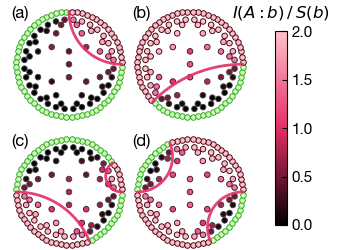

In [11]:
# ============================================================
# Visualization: 2x2 grid with MI/S(b) normalization
# ============================================================

from matplotlib.transforms import Bbox
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import colorsys
import matplotlib.colors as mcolors

# Import helper functions
from functions_for_04_cartography import (
    draw_rt_surface,
    draw_rt_surface_discontinuous,
    invert_lightness,
)

from graph2grav.figure_hashing import save_figure_with_hash

config = loco.reload()

# Set up figure output to match print size
bbox = Bbox.from_bounds(0.0, 0.0, 3.375, 2.5)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

# Colormap: black -> magenta -> pink
pink_black = LinearSegmentedColormap.from_list(
    "pink_black",
    ["black", "#e52d67ff", "pink"],
)
pink_black.set_under("black")
pink_black.set_over("pink")

# Visualization options
draw_rt_surface_flag = True
rt_color = config["graph"]["nodes"]["selected_boundary"].get("ryu_takayanagi", {}).get("color", "cyan")
rt_linewidth = 2.0

# Build radial layout (Poincaré disk) - same as decorated case
hyperbolic_spacing = 0.5
pos = {}

# First, set up depth information for each node
# For non-decorated graph, use tree_node_depth to compute depth
for node in G.nodes():
    if G.nodes[node].get('is_boundary'):
        # Boundary nodes go on the circle
        boundary_pos = G.nodes[node].get('position_in_boundary', 0)
        angular_position = 2 * np.pi * boundary_pos / len(boundary_nodes) + np.pi / len(boundary_nodes)
        radius = 1.0
    else:
        # Ancilla nodes - compute depth from tree structure
        node_depth = tree_node_depth(node)
        
        # Find all ancilla nodes at this depth
        nodes_at_depth = sorted([n for n in G.nodes() 
                                 if tree_node_depth(n) == node_depth 
                                 and not G.nodes[n].get('is_boundary')])
        
        if node in nodes_at_depth:
            node_idx = nodes_at_depth.index(node)
            n_at_depth = len(nodes_at_depth)
            angular_position = 2 * np.pi * node_idx / n_at_depth + np.pi / n_at_depth
        else:
            angular_position = 0
        
        # Hyperbolic radial coordinate (same as decorated case)
        euclidean_r = hyperbolic_spacing * node_depth
        radius = np.tanh(euclidean_r / 2)
    
    pos[node] = np.array([radius * np.cos(angular_position), radius * np.sin(angular_position)])

angular_spacing = 2 * np.pi / len(boundary_nodes)
angular_offset = angular_spacing / 2

# Figure setup: 2x2 grid with colorbar (same size as decorated)
fig = plt.figure(figsize=(bbox.width, bbox.height))
spec = gridspec.GridSpec(2, 4, hspace=0.1, wspace=0, width_ratios=[1, 1, 0.2, 0.1], left=0.025, bottom=0, top=0.975, right=0.85)
axes = [fig.add_subplot(spec[0, 0]), fig.add_subplot(spec[0, 1]), 
        fig.add_subplot(spec[1, 0]), fig.add_subplot(spec[1, 1])]

cgs = spec[:, 3].subgridspec(3, 1, height_ratios=[0.05, 0.90, 0.05])
cbar_ax = fig.add_subplot(cgs[1, 0])

# Node sizes and linewidths (same scale as decorated)
node_scale = 1 / 5
boundary_node_size = config["graph"]["nodes"]["boundary"]["outer"]["size"] * node_scale
ancilla_node_size = config["graph"]["nodes"]["ancilla"]["outer"]["size"] * node_scale
selected_boundary_node_size = config["graph"]["nodes"]["selected_boundary"]["outer"]["size"] * node_scale

boundary_linewidth = np.sqrt(boundary_node_size) * 0.165
ancilla_linewidth = np.sqrt(ancilla_node_size) * 0.165
selected_linewidth = np.sqrt(selected_boundary_node_size) * 0.165

cmap = pink_black
norm = Normalize(vmin=0, vmax=2)

for config_idx, (region_spec, title) in enumerate(region_configs):
    ax = axes[config_idx]
    
    # Parse region specification
    if isinstance(region_spec, int):
        selected_boundary = boundary_nodes[:region_spec]
        is_discontinuous = False
        regions = None
    else:
        selected_boundary = []
        regions = []
        for (start, end) in region_spec:
            selected_boundary.extend(boundary_nodes[start:end])
            first_node = boundary_nodes[start]
            last_node = boundary_nodes[end-1]
            p1 = pos[first_node]
            p2 = pos[last_node]
            theta1 = np.arctan2(p1[1], p1[0]) - angular_offset
            theta2 = np.arctan2(p2[1], p2[0]) + angular_offset
            regions.append((theta1, theta2))
        is_discontinuous = True
    
    unselected_boundary = [n for n in boundary_nodes if n not in selected_boundary]
    
    # Get pre-computed entropies for this configuration
    entropies_by_position = entropy_results_by_config[config_idx]
    
    # Compute normalized MI = MI / S_b
    normalized_MI_by_position = {}
    for n, ent in entropies_by_position.items():
        S_b = ent['S_b']
        MI = ent['MI_R_b']
        if S_b > 1e-10:
            normalized_MI_by_position[n] = MI / S_b
        else:
            normalized_MI_by_position[n] = 0.0
    
    # Draw RT surface
    if draw_rt_surface_flag:
        if is_discontinuous:
            draw_rt_surface_discontinuous(ax, boundary_nodes, regions,
                                          color=rt_color, linewidth=rt_linewidth,
                                          alpha=0.9, zorder=10)
        else:
            draw_rt_surface(ax, pos, boundary_nodes, selected_boundary,
                           color=rt_color, linewidth=rt_linewidth, alpha=0.9, zorder=10)
    
    # Draw unselected boundary nodes
    if unselected_boundary:
        nx.draw_networkx_nodes(G, pos, nodelist=unselected_boundary,
                              node_color=config["graph"]["nodes"]["boundary"]["inner"]["color"],
                              node_size=boundary_node_size,
                              edgecolors=config["graph"]["nodes"]["boundary"]["outer"]["color"],
                              linewidths=boundary_linewidth, ax=ax)
    
    # Draw selected boundary nodes
    nx.draw_networkx_nodes(G, pos, nodelist=selected_boundary,
                          node_color=config["graph"]["nodes"]["selected_boundary"]["inner"]["color"],
                          node_size=selected_boundary_node_size,
                          edgecolors=invert_lightness(cmap(1.0)),
                          linewidths=selected_linewidth, ax=ax)
    
    # Draw ancilla nodes colored by normalized MI
    probed_nodes = [n for n in ancilla_nodes if n in normalized_MI_by_position]
    if probed_nodes:
        node_colors = [cmap(norm(normalized_MI_by_position.get(n, 0.0))) for n in probed_nodes]
        
        nx.draw_networkx_nodes(G, pos, nodelist=probed_nodes,
                              node_color=node_colors,
                              node_size=ancilla_node_size,
                              edgecolors=[invert_lightness(c) for c in node_colors],
                              linewidths=ancilla_linewidth, ax=ax)

# Format all axes
for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=1)
    ax.add_artist(circle)
    ax.set_axis_off()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.ax.set_title(r'$I(A:b)\,/\,S(b)$', fontsize=12, pad=10)

# Add panel labels (a), (b), (c), (d)
for n, ax in enumerate(axes):
    letter = chr(ord('a') + n)
    ax.text(0, 1, f'({letter})', transform=ax.transAxes,
            fontsize=config['subfigure-label']['font']['size'], fontweight='bold', va='top', ha='left')

if export_outputs := True:
    save_figure_with_hash(fig, "figures/figure_4_undecorated_wedge_reconsruction.pdf", bbox_inches=bbox)